<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

# DOE Fatorial 2² — P1 × P2 (por política de Estoque)

### Simulação de Eventos Discretos

Análise Fatorial **2×2**

Em vez de tratar Estoque como um terceiro fator dentro do mesmo modelo, rodamos **duas análises fatoriais 2² separadas** — uma para cada política de estoque — usando exatamente a mesma estrutura de análise:

## Estrutura do Notebook

1. **Cálculo dos efeitos** (método dos contrastes)
2. **Intervalo de confiança (IC) dos efeitos**
3. **ANOVA fatorial** (teste de significância)

- **Fatores:** P1 ($15$ / $22$) e P2 ($20$ / $24$)
- **Réplicas:** 5 por tratamento (2×2×5 = 20 observações em cada análise)
- **KPI:** Lucro

## Configuração do ambiente

In [23]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

NAVY, AMBER = "#1A2744", "#E8A020"
plt.rcParams.update({"axes.edgecolor": NAVY, "axes.titleweight": "bold"})

## Dados

In [24]:
dados = pd.DataFrame([
    #  P1   P2      Estoque        R1     R2     R3     R4     R5
    [  15,  20, "separados",      3619,  3651,  3667,  3627,  3665],
    [  15,  20, "juntos",         3469,  3511,  3507,  3452,  3490],
    [  15,  24, "separados",      3739,  3776,  3792,  3782,  3815],
    [  15,  24, "juntos",         3516,  3548,  3579,  3512,  3555],
    [  22,  20, "separados",      3819,  3981,  4147,  4077,  4055],
    [  22,  20, "juntos",         2963,  3084,  3384,  3159,  3215],
    [  22,  24, "separados",      3939,  4106,  4272,  4232,  4205],
    [  22,  24, "juntos",         2963,  3084,  3384,  3159,  3215],
], columns=["P1", "P2", "Estoque", "R1", "R2", "R3", "R4", "R5"])

df = dados.melt(id_vars=["P1", "P2", "Estoque"], value_vars=["R1", "R2", "R3", "R4", "R5"],
                 var_name="replica", value_name="lucro")

df_separados = df[df["Estoque"] == "separados"].reset_index(drop=True)
df_juntos    = df[df["Estoque"] == "juntos"].reset_index(drop=True)

dados

,P1,P2,Estoque,R1,R2,R3,R4,R5
0,15,20,separados,3619,3651,3667,3627,3665
1,15,20,juntos,3469,3511,3507,3452,3490
2,15,24,separados,3739,3776,3792,3782,3815
3,15,24,juntos,3516,3548,3579,3512,3555
4,22,20,separados,3819,3981,4147,4077,4055
5,22,20,juntos,2963,3084,3384,3159,3215
6,22,24,separados,3939,4106,4272,4232,4205
7,22,24,juntos,2963,3084,3384,3159,3215


---
# 1. Análise fatorial P1 × P2 — Estoque **separado**

## 1.1 Cálculo dos efeitos (contrastes)

Codificamos P1 e P2 como $-1$ (nível baixo) / $+1$ (nível alto), calculamos a média de lucro de cada um dos 4 tratamentos e aplicamos o método dos contrastes: $\text{Efeito}_X = \frac{1}{2^{k-1}}\sum \text{sinal}_i(X)\cdot\bar y_i$, com $k=2$.

In [25]:
d_sep = df_separados.copy()
d_sep["A"] = d_sep["P1"].map({15: -1, 22: 1})
d_sep["B"] = d_sep["P2"].map({20: -1, 24: 1})

trat_sep = d_sep.groupby(["A", "B"])["lucro"].mean().reset_index()
trat_sep["AB"] = trat_sep["A"] * trat_sep["B"]

termos = ["A", "B", "AB"]
nomes = {"A": "P1", "B": "P2", "AB": "P1×P2"}
efeitos_sep = {t: (trat_sep[t] * trat_sep["lucro"]).sum() / 2 for t in termos}

tabela_sep = pd.DataFrame({"Termo": termos, "Fator": [nomes[t] for t in termos],
                            "Efeito": [efeitos_sep[t] for t in termos]})
tabela_sep.round(2)

,Termo,Fator,Efeito
0,A,P1,370.0
1,B,P2,135.0
2,AB,P1×P2,0.0


## 1.2 Intervalo de confiança (IC) dos efeitos

$$
\text{Var}(\text{Efeito}) = \frac{4\,\sigma^2}{N} \quad\Rightarrow\quad EP(\text{Efeito}) = 2\sqrt{\frac{\sigma^2}{N}}
\qquad\qquad
\text{IC} = \text{Efeito} \pm t_{\alpha/2,\;N-2^k}\cdot EP(\text{Efeito})
$$

$\sigma^2$ é estimada pelo quadrado médio residual (MSE) do modelo saturado ($N=20$, $2^k=4$ tratamentos, $16$ graus de liberdade de erro puro).

In [26]:
modelo_sep = ols("lucro ~ C(P1) * C(P2)", data=d_sep).fit()
anova_sep = sm.stats.anova_lm(modelo_sep, typ=2)

N_sep = len(d_sep)
gl_sep = anova_sep.loc["Residual", "df"]
mse_sep = anova_sep.loc["Residual", "sum_sq"] / gl_sep
ep_sep = 2 * np.sqrt(mse_sep / N_sep)
tcrit_sep = stats.t.ppf(0.975, gl_sep)
margem_sep = tcrit_sep * ep_sep

tabela_sep["EP"] = ep_sep
tabela_sep["IC 95% (inf.)"] = tabela_sep["Efeito"] - margem_sep
tabela_sep["IC 95% (sup.)"] = tabela_sep["Efeito"] + margem_sep
tabela_sep["Significativo (IC 95%)"] = np.where(
    (tabela_sep["IC 95% (inf.)"] > 0) | (tabela_sep["IC 95% (sup.)"] < 0), "Sim ✅", "Não ⛔")
tabela_sep["|Efeito|"] = tabela_sep["Efeito"].abs()
tabela_sep = tabela_sep.sort_values("|Efeito|", ascending=False).reset_index(drop=True)

print(f"MSE = {mse_sep:.1f}  |  gl residual = {int(gl_sep)}  |  EP(efeito) = {ep_sep:.1f}  |  margem 95% = {margem_sep:.1f}")
tabela_sep.round(1)

MSE = 8656.7  |  gl residual = 16  |  EP(efeito) = 41.6  |  margem 95% = 88.2


,Termo,Fator,Efeito,EP,IC 95% (inf.),IC 95% (sup.),Significativo (IC 95%),|Efeito|
0,A,P1,370.0,41.6,281.8,458.2,Sim ✅,370.0
1,B,P2,135.0,41.6,46.8,223.2,Sim ✅,135.0
2,AB,P1×P2,0.0,41.6,-88.2,88.2,Não ⛔,0.0


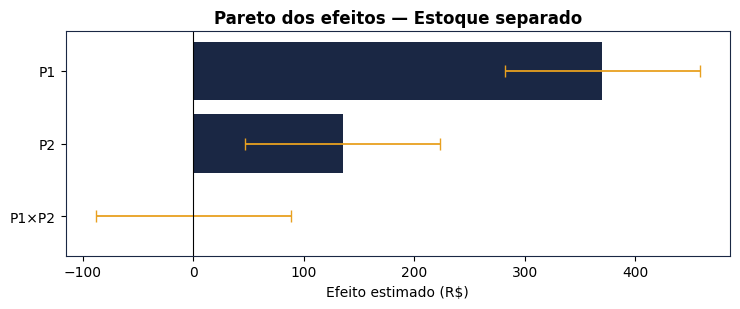

In [27]:
ordem = tabela_sep.sort_values("|Efeito|")
cores = [NAVY if s == "Sim ✅" else "#B0B0B0" for s in ordem["Significativo (IC 95%)"]]
plt.figure(figsize=(7.5, 3.2))
plt.barh(ordem["Fator"], ordem["Efeito"], xerr=margem_sep, color=cores, capsize=4,
         error_kw={"elinewidth": 1.3, "ecolor": AMBER})
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pareto dos efeitos — Estoque separado")
plt.xlabel("Efeito estimado (R$)")
plt.tight_layout()
plt.show()

## 1.3 ANOVA fatorial (Estoque separado)

In [28]:
anova_sep_view = anova_sep.round(4)
anova_sep_view["Conclusão"] = anova_sep_view["PR(>F)"].apply(
    lambda p: "Significativo ✅" if p < 0.05 else "Não significativo ⛔")
anova_sep_view

,sum_sq,df,F,PR(>F),Conclusão
C(P1),684500.0,1.0,79.0717,0.0000,Significativo ✅
C(P2),91125.0,1.0,10.5265,0.0051,Significativo ✅
C(P1):C(P2),0.0,1.0,0.0000,1.0000,Não significativo ⛔
Residual,138507.2,16.0,NaN,NaN,Não significativo ⛔


---
# 2. Análise fatorial P1 × P2 — Estoque **junto**

## 2.1 Cálculo dos efeitos (contrastes)

In [29]:
d_jun = df_juntos.copy()
d_jun["A"] = d_jun["P1"].map({15: -1, 22: 1})
d_jun["B"] = d_jun["P2"].map({20: -1, 24: 1})

trat_jun = d_jun.groupby(["A", "B"])["lucro"].mean().reset_index()
trat_jun["AB"] = trat_jun["A"] * trat_jun["B"]

efeitos_jun = {t: (trat_jun[t] * trat_jun["lucro"]).sum() / 2 for t in termos}

tabela_jun = pd.DataFrame({"Termo": termos, "Fator": [nomes[t] for t in termos],
                            "Efeito": [efeitos_jun[t] for t in termos]})
tabela_jun.round(2)

,Termo,Fator,Efeito
0,A,P1,-352.9
1,B,P2,28.1
2,AB,P1×P2,-28.1


## 2.2 Intervalo de confiança (IC) dos efeitos

In [30]:
modelo_jun = ols("lucro ~ C(P1) * C(P2)", data=d_jun).fit()
anova_jun = sm.stats.anova_lm(modelo_jun, typ=2)

N_jun = len(d_jun)
gl_jun = anova_jun.loc["Residual", "df"]
mse_jun = anova_jun.loc["Residual", "sum_sq"] / gl_jun
ep_jun = 2 * np.sqrt(mse_jun / N_jun)
tcrit_jun = stats.t.ppf(0.975, gl_jun)
margem_jun = tcrit_jun * ep_jun

tabela_jun["EP"] = ep_jun
tabela_jun["IC 95% (inf.)"] = tabela_jun["Efeito"] - margem_jun
tabela_jun["IC 95% (sup.)"] = tabela_jun["Efeito"] + margem_jun
tabela_jun["Significativo (IC 95%)"] = np.where(
    (tabela_jun["IC 95% (inf.)"] > 0) | (tabela_jun["IC 95% (sup.)"] < 0), "Sim ✅", "Não ⛔")
tabela_jun["|Efeito|"] = tabela_jun["Efeito"].abs()
tabela_jun = tabela_jun.sort_values("|Efeito|", ascending=False).reset_index(drop=True)

print(f"MSE = {mse_jun:.1f}  |  gl residual = {int(gl_jun)}  |  EP(efeito) = {ep_jun:.1f}  |  margem 95% = {margem_jun:.1f}")
tabela_jun.round(1)

MSE = 12577.5  |  gl residual = 16  |  EP(efeito) = 50.2  |  margem 95% = 106.3


,Termo,Fator,Efeito,EP,IC 95% (inf.),IC 95% (sup.),Significativo (IC 95%),|Efeito|
0,A,P1,-352.9,50.2,-459.2,-246.6,Sim ✅,352.9
1,B,P2,28.1,50.2,-78.2,134.4,Não ⛔,28.1
2,AB,P1×P2,-28.1,50.2,-134.4,78.2,Não ⛔,28.1


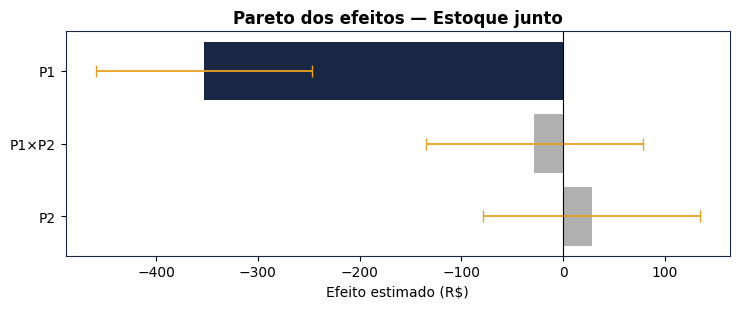

In [31]:
ordem = tabela_jun.sort_values("|Efeito|")
cores = [NAVY if s == "Sim ✅" else "#B0B0B0" for s in ordem["Significativo (IC 95%)"]]
plt.figure(figsize=(7.5, 3.2))
plt.barh(ordem["Fator"], ordem["Efeito"], xerr=margem_jun, color=cores, capsize=4,
         error_kw={"elinewidth": 1.3, "ecolor": AMBER})
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Pareto dos efeitos — Estoque junto")
plt.xlabel("Efeito estimado (R$)")
plt.tight_layout()
plt.show()

## 2.3 ANOVA fatorial (Estoque junto)

In [32]:
anova_jun_view = anova_jun.round(4)
anova_jun_view["Conclusão"] = anova_jun_view["PR(>F)"].apply(
    lambda p: "Significativo ✅" if p < 0.05 else "Não significativo ⛔")
anova_jun_view

,sum_sq,df,F,PR(>F),Conclusão
C(P1),622692.05,1.0,49.5082,0.0000,Significativo ✅
C(P2),3948.05,1.0,0.3139,0.5831,Não significativo ⛔
C(P1):C(P2),3948.05,1.0,0.3139,0.5831,Não significativo ⛔
Residual,201240.80,16.0,NaN,NaN,Não significativo ⛔


---
# 3. Conclusão

In [33]:
comparacao = (tabela_sep[["Fator", "Efeito"]].rename(columns={"Efeito": "Efeito (separado)"})
              .merge(tabela_jun[["Fator", "Efeito"]].rename(columns={"Efeito": "Efeito (junto)"}), on="Fator"))
comparacao["Diferença (junto - separado)"] = comparacao["Efeito (junto)"] - comparacao["Efeito (separado)"]
comparacao

,Fator,Efeito (separado),Efeito (junto),Diferença (junto - separado)
0,P1,370.0,-352.9,-722.9
1,P2,135.0,28.1,-106.9
2,P1×P2,0.0,-28.1,-28.1


**Estoque separado:**

- **P1** tem o maior efeito (≈ **+370**, significativo): comprar mais de P1 (15→22) aumenta bastante o lucro.
- **P2** também é positivo e significativo (≈ **+135**): comprar mais de P2 (20→24) também ajuda, em menor grau.
- **P1 × P2** é praticamente zero e não significativo: os fatores agem de forma **independente** — a melhor decisão é simplesmente "aumente os dois". O tratamento `P1=alto, P2=alto` é o de maior lucro médio observado.

**Estoque junto:**

- **P1** continua sendo o efeito dominante, mas com o **sinal invertido** (≈ **-353**, significativo): comprar mais de P1 **reduz** o lucro quando o estoque é compartilhado.
- **P2** deixa de ser significativo (≈ +28, IC cruza o zero): a quantidade comprada de P2 não tem efeito estatisticamente confiável sobre o lucro neste regime.
- **P1 × P2** também não é significativo (≈ -28).

**Por que isso importa — a política de estoque muda a decisão de compra:** o efeito de P1 vai de **+370** (separado) para **-353** (junto) — uma inversão completa de sinal. Esse achado reforça que **a política de estoque não é uma decisão neutra**: ela determina se comprar mais de P1 é uma boa ou uma má ideia.

**Recomendação:**

- **Cenário preferencial:** `Estoque separado, P1 alto, P2 alto` — maior lucro médio entre todos os tratamentos testados (~R\$ 4.151).
- Se, por restrição operacional, os estoques precisarem ficar `juntos`, a recomendação se inverte: **reduzir P1**, já que aumentá-lo nesse regime destrói valor, e não há evidência de que aumentar P2 compense a diferença.

**Próximo passo da sequência de ensino:** o notebook fatorial $2^3$ (P1 × P2 × Estoque) formaliza essa mesma conclusão dentro de um único modelo, através do termo de interação P1×Estoque — mostrando que dividir a análise em dois fatoriais 2² (como fizemos aqui) e rodar um único fatorial 2³ levam à mesma conclusão, por caminhos diferentes.

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## Referências

- Montgomery, D. C. (2020). *Design and Analysis of Experiments*. 10a ed. Wiley.
- Box, G. E. P., Hunter, J. S., & Hunter, W. G. (2005). *Statistics for Experimenters: Design, Innovation, and Discovery*. 2a ed. Wiley.
- Barros Neto, B., Scarminio, I. S., & Bruns, R. E. (2010). *Como Fazer Experimentos: Pesquisa e Desenvolvimento na Ciência e na Indústria*. 4a ed. Bookman.
- Law, A. M. (2015). *Simulation Modeling and Analysis*. 5a ed. McGraw-Hill.


## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 30-07-2026       | 1.0     | Eduardo Pecora    | Inicial               ||

<hr>

<h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>